In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

In [17]:
df = pd.read_csv("/content/amazon_prime_titles.csv")
print(df.head())

  show_id   type                 title        director  \
0      s1  Movie   The Grand Seduction    Don McKellar   
1      s2  Movie  Take Care Good Night    Girish Joshi   
2      s3  Movie  Secrets of Deception     Josh Webber   
3      s4  Movie    Pink: Staying True  Sonia Anderson   
4      s5  Movie         Monster Maker    Giles Foster   

                                                cast         country  \
0     Brendan Gleeson, Taylor Kitsch, Gordon Pinsent          Canada   
1   Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar           India   
2  Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...   United States   
3  Interviews with: Pink, Adele, Beyoncé, Britney...   United States   
4  Harry Dean Stanton, Kieran O'Brien, George Cos...  United Kingdom   

       date_added  release_year rating duration                listed_in  \
0  March 30, 2021          2014    NaN  113 min            Comedy, Drama   
1  March 30, 2021          2018    13+  110 min     Drama, Interna

In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       9668 non-null   object
 1   type          9668 non-null   object
 2   title         9668 non-null   object
 3   director      7585 non-null   object
 4   cast          8435 non-null   object
 5   country       672 non-null    object
 6   date_added    155 non-null    object
 7   release_year  9668 non-null   int64 
 8   rating        9331 non-null   object
 9   duration      9668 non-null   object
 10  listed_in     9668 non-null   object
 11  description   9668 non-null   object
dtypes: int64(1), object(11)
memory usage: 906.5+ KB
None


In [24]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nColumns:")
print(df.columns)

Dataset Shape:
(9668, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       9668 non-null   object
 1   type          9668 non-null   object
 2   title         9668 non-null   object
 3   director      7585 non-null   object
 4   cast          8435 non-null   object
 5   country       672 non-null    object
 6   date_added    155 non-null    object
 7   release_year  9668 non-null   int64 
 8   rating        9331 non-null   object
 9   duration      9668 non-null   object
 10  listed_in     9668 non-null   object
 11  description   9668 non-null   object
dtypes: int64(1), object(11)
memory usage: 906.5+ KB
None

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [15]:
print(df.isnull().sum())


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [25]:
for col in ['director', 'cast', 'country', 'rating']:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added      9513
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64


/tmp/ipykernel_2245/1011632623.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [26]:
print(df.dtypes)

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [27]:
df['date_added'] = pd.to_datetime(df['date_added'])

print(df['date_added'].head())

0   2021-03-30
1   2021-03-30
2   2021-03-30
3   2021-03-30
4   2021-03-30
Name: date_added, dtype: datetime64[ns]


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    'type',
    'title',
    'director',
    'cast',
    'country',
    'rating',
    'duration',
    'listed_in'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col].astype(str))

print(df.head())

  show_id  type  title  director  cast  country date_added  release_year  \
0      s1     0   8008      1464   984        8 2021-03-30          2014   
1      s2     0   7488      1898  4639       26 2021-03-30          2018   
2      s3     0   6796      2789  7384       60 2021-03-30          2017   
3      s4     0   6038      5017  2932       60 2021-03-30          2014   
4      s5     0   5225      1888  2760       51 2021-03-30          1989   

   rating  duration  listed_in  \
0       0        20        267   
1       0        17        387   
2       0       189         71   
3       0       182        321   
4       0       146        368   

                                         description  
0  A small fishing village must procure a local d...  
1  A Metro Family decides to fight a Cyber Crimin...  
2  After a man discovers his wife is cheating on ...  
3  Pink breaks the mold once again, bringing her ...  
4  Teenage Matt Banting wants to work with a famo...  


In [29]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

print(numerical_columns)

Index(['type', 'title', 'director', 'cast', 'country', 'release_year',
       'rating', 'duration', 'listed_in'],
      dtype='object')


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print(df.head())

  show_id    type     title  director      cast   country date_added  \
0      s1 -0.4871  1.137442 -1.039407 -1.414660 -7.680535 2021-03-30   
1      s2 -0.4871  0.951123 -0.747729  0.280061 -4.960324 2021-03-30   
2      s3 -0.4871  0.703175 -0.148916  1.552840  0.177852 2021-03-30   
3      s4 -0.4871  0.431579  1.348455 -0.511427  0.177852 2021-03-30   
4      s5 -0.4871  0.140277 -0.754450 -0.591179 -1.182253 2021-03-30   

   release_year   rating  duration  listed_in  \
0      0.299033 -0.97539 -1.122600  -0.245470   
1      0.510433 -0.97539 -1.157589   0.552610   
2      0.457583 -0.97539  0.848451  -1.549000   
3      0.299033 -0.97539  0.766810   0.113666   
4     -1.022215 -0.97539  0.346941   0.426247   

                                         description  
0  A small fishing village must procure a local d...  
1  A Metro Family decides to fight a Cyber Crimin...  
2  After a man discovers his wife is cheating on ...  
3  Pink breaks the mold once again, bringing her ...

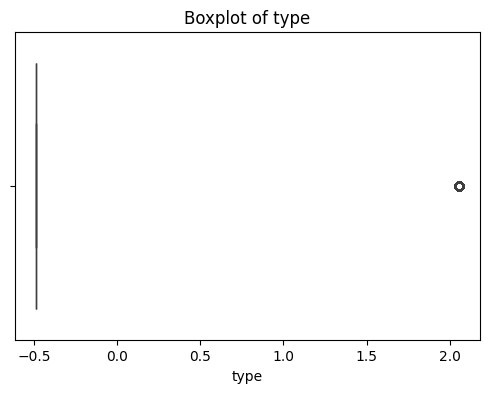

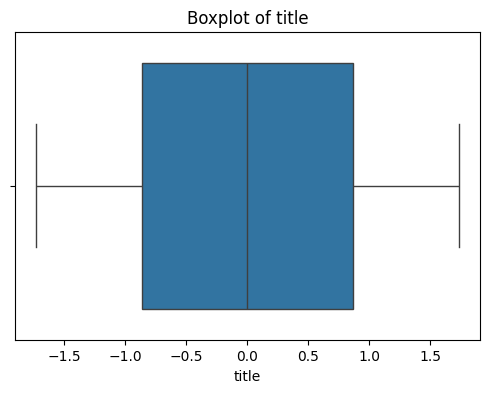

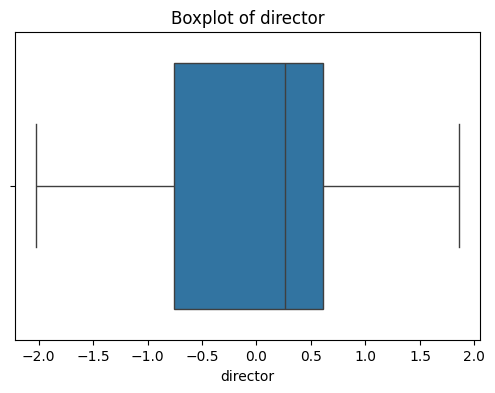

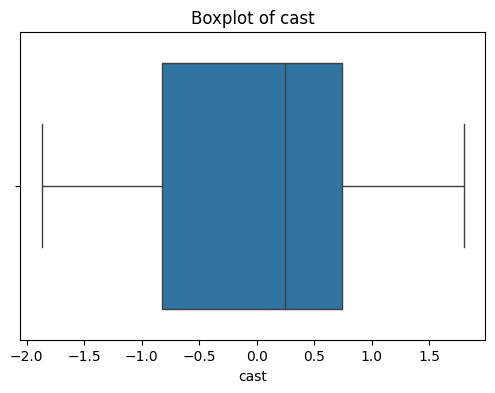

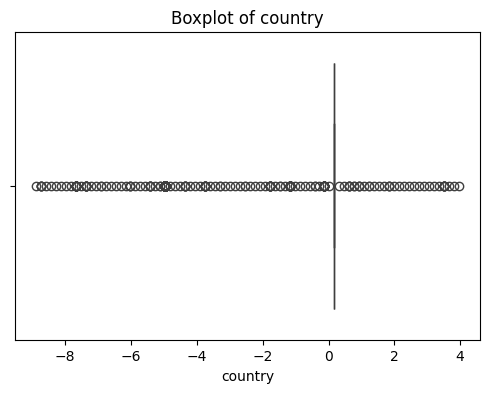

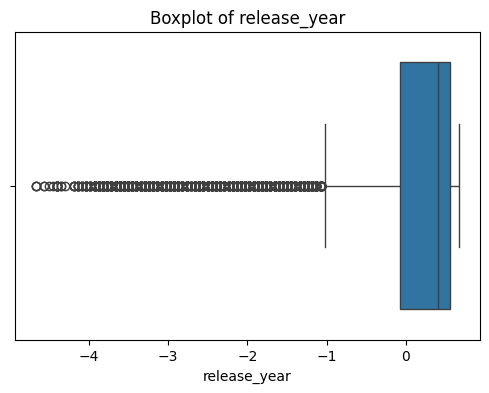

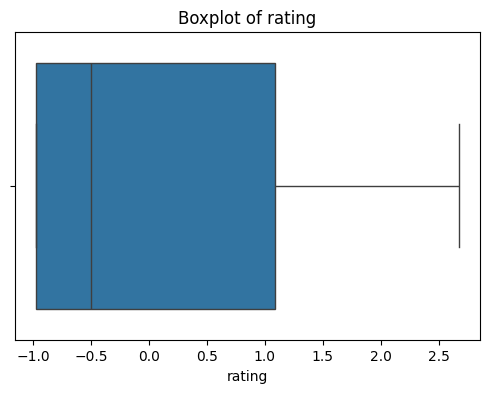

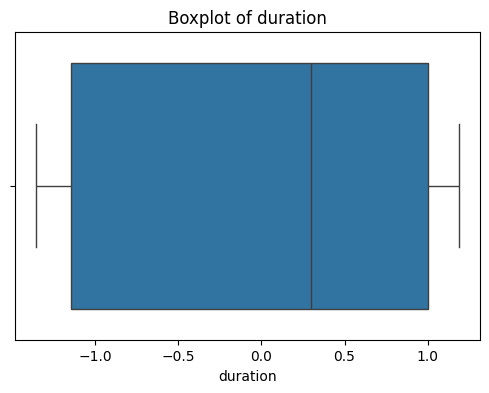

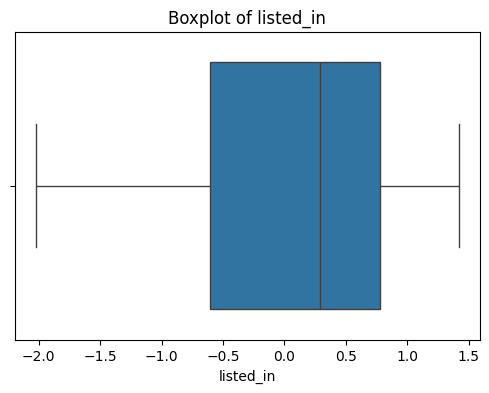

In [31]:
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [32]:
for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Dataset Shape After Removing Outliers:")
print(df.shape)

Dataset Shape After Removing Outliers:
(6579, 12)


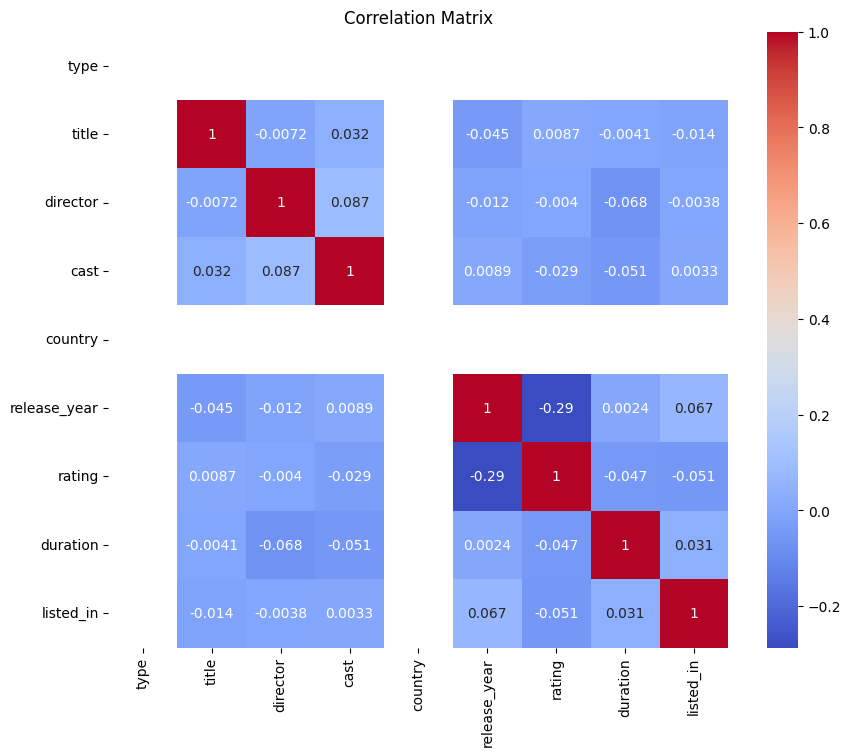

In [33]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [34]:
df.to_csv("cleaned_amazon_prime_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
